# figures_si.ipynb

Supplementary Information figures for the VAE-HMM convection paper.  
All shared utilities live in [`workflow_paper.py`](../workflow_paper.py).

**Structure**: imports → data loading → one cell per SI figure.

## 1 · Imports

In [1]:
import sys
sys.path.insert(0, '/Users/sophieabramian/Documents/troposwhere/paper')

import os
import pickle
import importlib
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import LogLocator
from scipy.stats import norm
from sklearn.decomposition import PCA as _PCA

import workflow_paper as wfp
importlib.reload(wfp)

# Viz constants
NUM_STATES    = wfp.NUM_STATES
state_colors  = wfp.state_colors
cluster_cmap  = wfp.cluster_cmap
norm_state    = wfp.norm_state
path_save_fig = wfp.FIGURES_SI_DIR
os.makedirs(path_save_fig, exist_ok=True)

## 2 · Data loading

Model inference, training history, experiment comparison paths, PCA 3D.

In [12]:
# ── Model & latents ──────────────────────────────────────────
loader, input_dim = wfp.load_dataloader()
model             = wfp.load_model(input_dim=input_dim)
out               = wfp.extract_latents(model, loader)
embeddings        = out["embeddings"]
states            = out["states"]
emb_pca, _        = wfp.run_pca(embeddings)
_, state_keep_indices = wfp.keep_closest_latent_samples(embeddings, states)

# ── Physical grids & log data ─────────────────────────────────
S, Z    = wfp.load_physical_grids()
data    = np.load(wfp.PATHS["data_log"])
if data.ndim > 2:
    data = data.reshape(len(data), -1)

vmin, vmax = -4, 4
levels = np.sort(np.unique(np.concatenate([
    np.linspace(-12, -5, 3), np.linspace(-5, -1, 8),
    np.linspace(-1, 1, 20),  np.linspace(1, 5, 8),
    np.linspace(5, 12, 3)
])))

# ── Training history ──────────────────────────────────────────
exp_dir_paper = os.path.join(wfp._RUNS, 'exp_20260220_1809_7a8b88_paper')
with open(os.path.join(exp_dir_paper, 'loss_history.pkl'), 'rb') as f:
    loss_dict = pickle.load(f)

def _parse_logs(logs):
    keys = ["total", "recon", "kl_scaled", "hmm_scaled",
            "entropy_unscaled", "trans_acc", "dice_loss_scaled"]
    return {k: np.array([d[k] for d in logs]) for k in keys}

epochs          = np.arange(len(loss_dict["train"]))
loss_series     = _parse_logs(loss_dict["train"])
val_loss_series = _parse_logs(loss_dict["val"])

# ── Latent-dimension comparison experiments ───────────────────
exp_ld4  = os.path.join(wfp._RUNS, 'exp_20260223_1623_a867a9')   # latent_dim=4
exp_ld16 = os.path.join(wfp._RUNS, 'exp_20260224_1725_4a7b6d')   # latent_dim=16
exp_compare = {4: exp_ld4, 8: exp_dir_paper, 16: exp_ld16}

def extract_recon_loss(exp_dir):
    with open(os.path.join(exp_dir, "loss_history.pkl"), "rb") as f:
        h = pickle.load(f)
    return np.array([d["recon"] for d in h["train"]])

# ── PCA 3D ────────────────────────────────────────────────────
pca3       = _PCA(n_components=3)
emb_pca_3d = pca3.fit_transform(embeddings)

## SI Fig. 1 — Training loss (`training_loss.pdf`)

Log-scale training curves for each loss component over epochs.

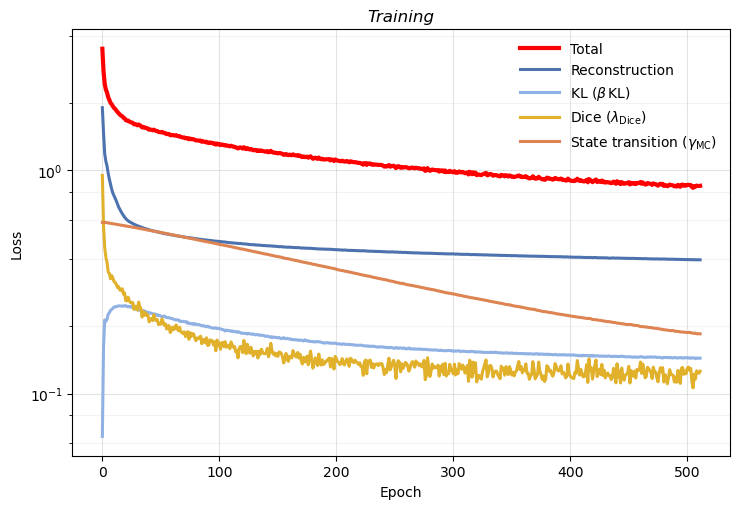

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.plot(epochs, loss_series["total"],            label="Total",                                    lw=3.0, color="r",       zorder=5)
ax.plot(epochs, loss_series["recon"],            label="Reconstruction",                           lw=2.2, color="#4C72B0")
ax.plot(epochs, loss_series["kl_scaled"],        label=r"KL ($\beta\,\mathrm{KL}$)",           lw=2.2, color="#8FB1E3")
ax.plot(epochs, loss_series["dice_loss_scaled"], label=r"Dice ($\lambda_{\mathrm{Dice}}$)",     lw=2.2, color="#E1B12C")
ax.plot(epochs, loss_series["hmm_scaled"],       label=r"State transition ($\gamma_{\mathrm{MC}}$)", lw=2.2, color="#DD8452")
ax.set_yscale("log"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(0.2, 0.4, 0.6, 0.8)))
ax.grid(which="major", alpha=0.35); ax.grid(which="minor", alpha=0.15)
ax.legend(frameon=False, fontsize=10, loc="upper right", handlelength=2.8)
ax.set_title("Training", style="italic")
plt.tight_layout()
plt.savefig(os.path.join(path_save_fig, "training_loss.pdf"))
plt.show()

## SI Fig. 2 — Validation loss (`validation_loss.pdf`)

Same as Fig. 1 but on the held-out validation set (dashed lines).

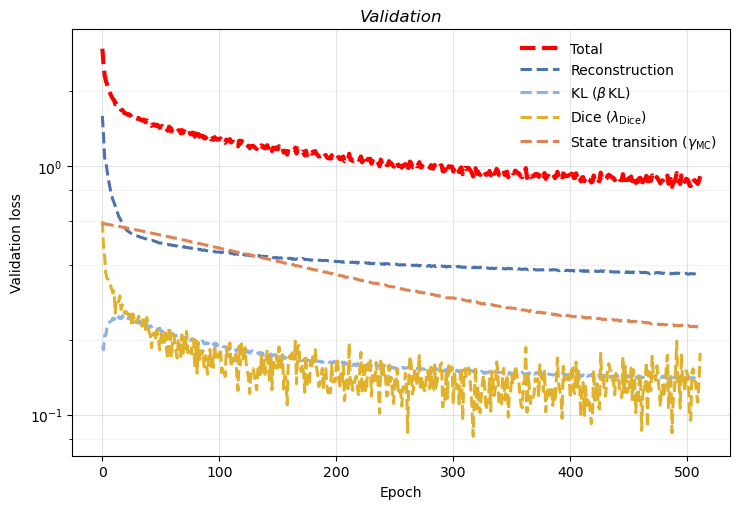

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.plot(epochs, val_loss_series["total"],            label="Total",           lw=3.0, ls="--", color="r",       zorder=5)
ax.plot(epochs, val_loss_series["recon"],            label="Reconstruction",  lw=2.2, ls="--", color="#4C72B0")
ax.plot(epochs, val_loss_series["kl_scaled"],        label=r"KL ($\beta\,\mathrm{KL}$)", lw=2.2, ls="--", color="#8FB1E3")
ax.plot(epochs, val_loss_series["dice_loss_scaled"], label=r"Dice ($\lambda_{\mathrm{Dice}}$)", lw=2.2, ls="--", color="#E1B12C")
ax.plot(epochs, val_loss_series["hmm_scaled"],       label=r"State transition ($\gamma_{\mathrm{MC}}$)", lw=2.2, ls="--", color="#DD8452")
ax.set_yscale("log"); ax.set_xlabel("Epoch"); ax.set_ylabel("Validation loss")
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(0.2, 0.4, 0.6, 0.8)))
ax.grid(which="major", alpha=0.35); ax.grid(which="minor", alpha=0.15)
ax.legend(frameon=False, fontsize=10, loc="upper right", handlelength=2.8)
ax.set_title("Validation", style="italic")
plt.tight_layout()
plt.savefig(os.path.join(path_save_fig, "validation_loss.pdf"))
plt.show()

## SI Fig. 3 — State entropy & transition accuracy (`entropy_trans_acc.pdf`)

Diagnostics tracking state collapse and HMM prediction quality during training.

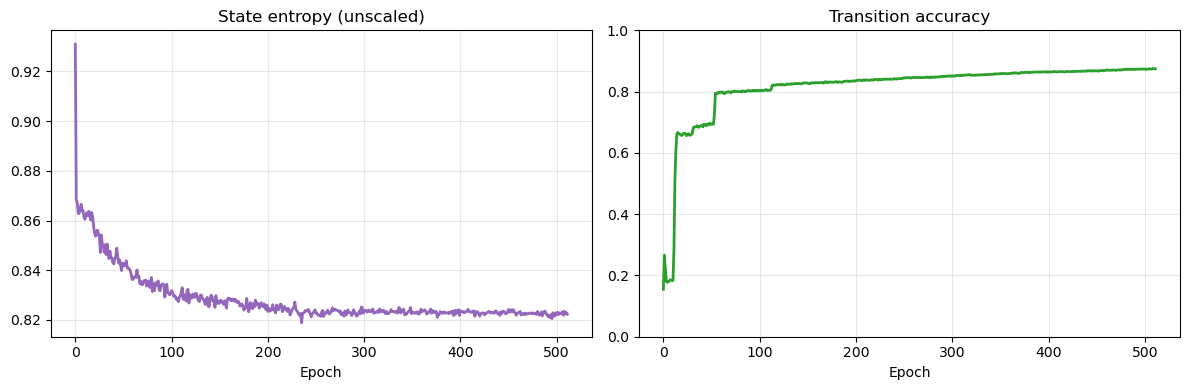

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_series["entropy_unscaled"], lw=2, color="tab:purple")
axes[0].set_title("State entropy (unscaled)"); axes[0].set_xlabel("Epoch"); axes[0].grid(True, alpha=0.3)
axes[1].plot(epochs, loss_series["trans_acc"], lw=2, color="tab:green")
axes[1].set_title("Transition accuracy"); axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(path_save_fig, "entropy_trans_acc.pdf"))
plt.show()

## SI Fig. 4 — Reconstruction examples (`reconstruction.pdf`)

Random sample vs VAE reconstruction for representative states.

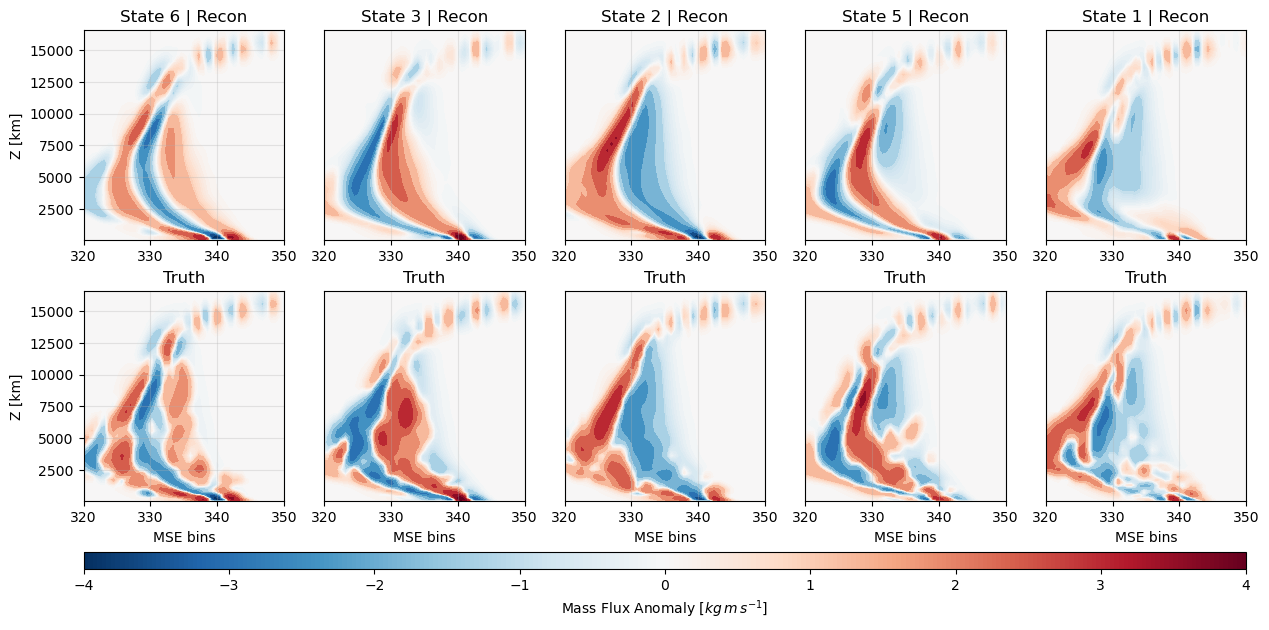

In [6]:
states_to_plot = [6, 3, 2, 5, 1]
rng = np.random.default_rng(0)
device = next(model.parameters()).device

fig = plt.figure(figsize=(3 * len(states_to_plot), 7))
gs  = fig.add_gridspec(3, len(states_to_plot), height_ratios=[1, 1, 0.08], hspace=0.35)
ax  = np.empty((2, len(states_to_plot)), dtype=object)
for j in range(len(states_to_plot)):
    ax[0, j] = fig.add_subplot(gs[0, j])
    ax[1, j] = fig.add_subplot(gs[1, j], sharex=ax[0, j], sharey=ax[0, j])
cax = fig.add_subplot(gs[2, :])

for j, s in enumerate(states_to_plot):
    idx = rng.choice(state_keep_indices[s])
    z_t = torch.tensor(embeddings[idx], dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        recon_flat = model.decoder(z_t).cpu().numpy()[0]
    recon_img = wfp.create_image_from_flat_tensor_np(recon_flat)[0]
    true_img  = wfp.create_image_from_flat_tensor_np(data[idx])[0]
    ax[0, j].contourf(S, Z, recon_img, levels=levels, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax[1, j].contourf(S, Z, true_img,  levels=levels, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax[0, j].set_title(f"State {s} | Recon"); ax[1, j].set_title("Truth")
    for row in [0, 1]: ax[row, j].grid(True, alpha=0.3)
    if j == 0:
        ax[0, j].set_ylabel("Z [km]"); ax[1, j].set_ylabel("Z [km]")
    else:
        ax[0, j].set_yticks([]); ax[1, j].set_yticks([])
    ax[1, j].set_xlabel("MSE bins")

sm = plt.cm.ScalarMappable(norm=mcolors.Normalize(vmin=vmin, vmax=vmax), cmap="RdBu_r")
sm.set_array([])
fig.colorbar(sm, cax=cax, orientation="horizontal",
             label=r"Mass Flux Anomaly [$kg\,m\,s^{-1}$]")
plt.savefig(os.path.join(path_save_fig, "reconstruction.pdf"))
plt.show()

## SI Fig. 5 — Canonical state representatives (`canonical_representative.pdf`)

Mean input ⟨x⟩ and decoder output Dec(⟨z⟩) per state.

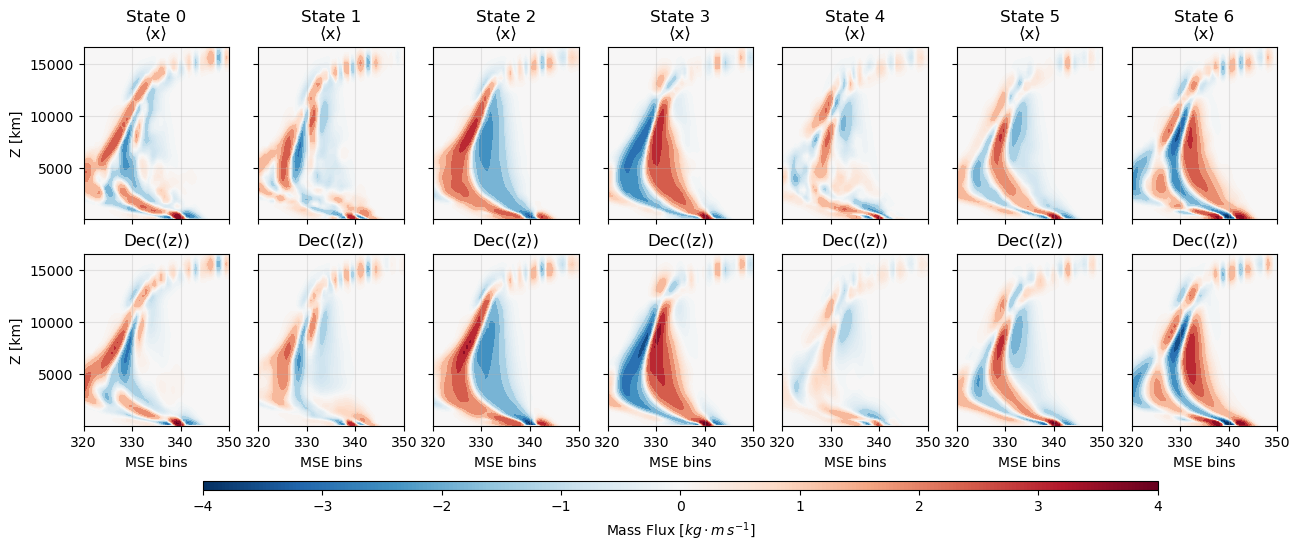

In [7]:
states_to_plot = sorted(state_keep_indices.keys())
device = next(model.parameters()).device

fig, ax = plt.subplots(2, len(states_to_plot),
                       figsize=(2.2 * len(states_to_plot), 6), sharex=True, sharey=True)

for j, s in enumerate(states_to_plot):
    idxs = state_keep_indices[s]
    mean_orig_img  = wfp.create_image_from_flat_tensor_np(data[idxs].mean(axis=0))[0]
    mean_latent_t  = torch.tensor(embeddings[idxs].mean(axis=0),
                                  dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        mean_recon_img = wfp.create_image_from_flat_tensor_np(
            model.decoder(mean_latent_t).cpu().numpy()[0])[0]

    ax[0, j].contourf(S, Z, mean_orig_img,  levels=levels, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax[1, j].contourf(S, Z, mean_recon_img, levels=levels, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax[0, j].set_title(f"State {s}\n⟨x⟩"); ax[1, j].set_title("Dec(⟨z⟩)")
    for row in [0, 1]: ax[row, j].grid(True, alpha=0.3)
    if j == 0:
        ax[0, j].set_ylabel("Z [km]"); ax[1, j].set_ylabel("Z [km]")
    ax[1, j].set_xlabel("MSE bins")

sm = plt.cm.ScalarMappable(norm=mcolors.Normalize(vmin=vmin, vmax=vmax), cmap="RdBu_r")
sm.set_array([])
fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.06, pad=0.12,
             label=r"Mass Flux [$kg\cdot m\,s^{-1}$]", aspect=110, shrink=0.8)
plt.savefig(os.path.join(path_save_fig, "canonical_representative.pdf"))
plt.show()

## SI Fig. 6 — Latent dimension sensitivity (`latent_dim_sensitivity.pdf`)

Reconstruction loss for models trained with latent dim ∈ {4, 8, 16}.

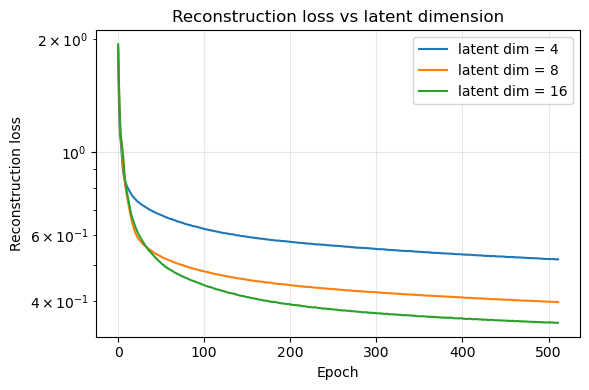

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
for latent_dim, exp_dir in exp_compare.items():
    ax.plot(extract_recon_loss(exp_dir), label=f"latent dim = {latent_dim}")
ax.set_yscale("log"); ax.set_xlabel("Epoch"); ax.set_ylabel("Reconstruction loss")
ax.set_title("Reconstruction loss vs latent dimension")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(path_save_fig, "latent_dim_sensitivity.pdf"))
plt.show()

## SI Fig. 7 — PCA 3D projection (`pca_3d.pdf`)

All three pairwise projections of the 3-component PCA embedding, coloured by state.

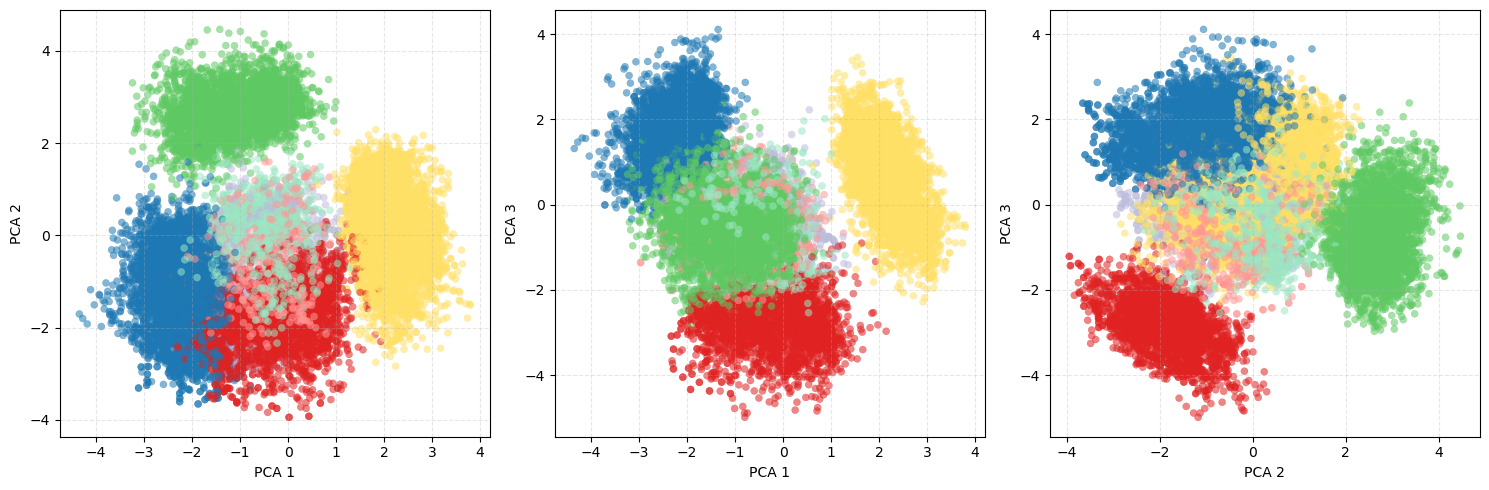

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [(0, 1, "PCA 1", "PCA 2"), (0, 2, "PCA 1", "PCA 3"), (1, 2, "PCA 2", "PCA 3")]
for ax, (i, j, xl, yl) in zip(axes, pairs):
    ax.scatter(emb_pca_3d[:, i], emb_pca_3d[:, j], c=states,
               cmap=cluster_cmap, norm=norm_state, s=26, alpha=0.55, linewidth=0.25)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(path_save_fig, "pca_3d.pdf"))
plt.show()

## SI Fig. 8 — Latent dimension distributions (`latent_dimensions.pdf`)

Histograms of each latent dimension vs the unit-normal prior N(0,1).

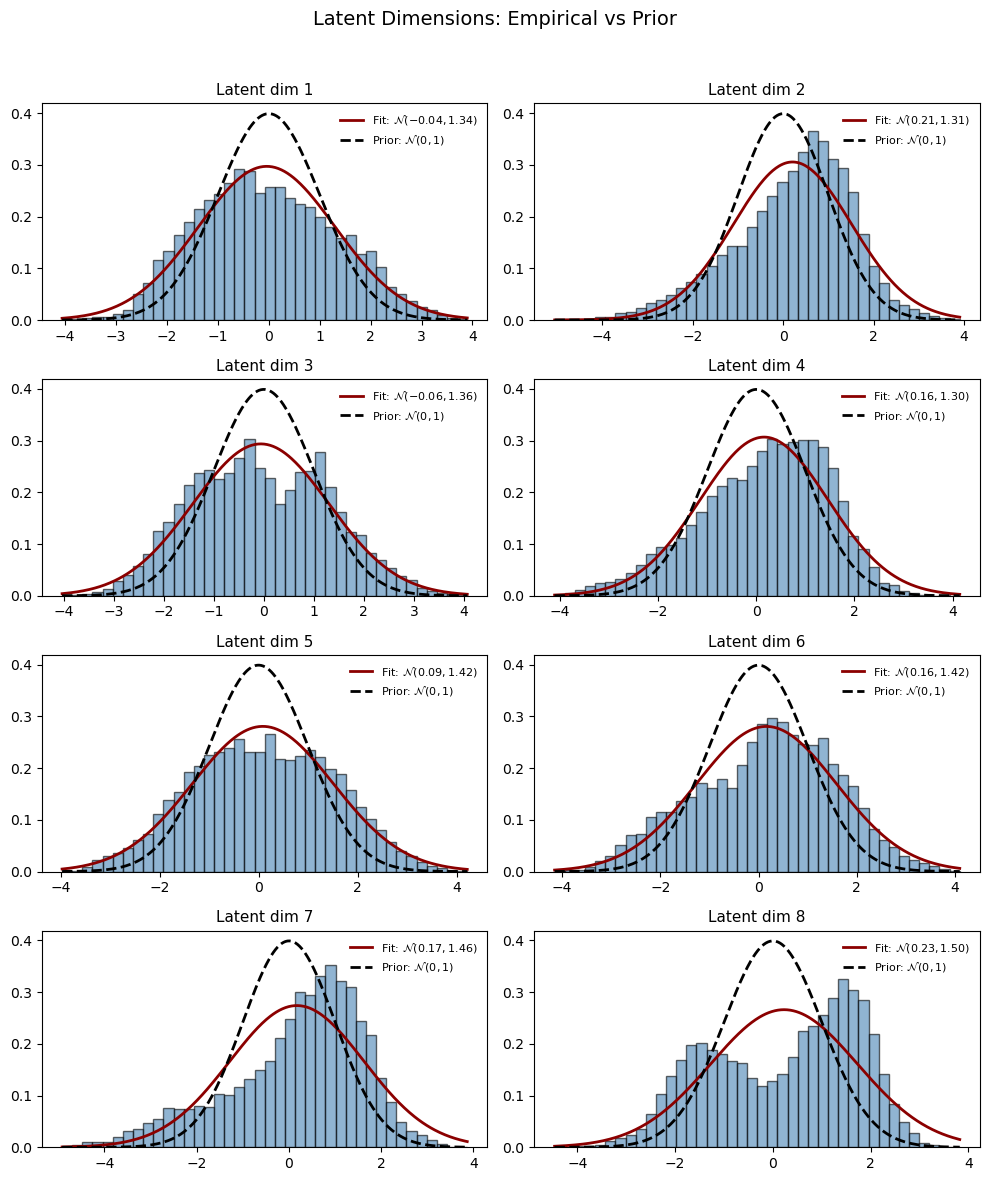

In [15]:
fig, axes = plt.subplots(4, 2, figsize=(10, 12))
for i, ax in enumerate(axes.flatten()):
    emb = embeddings[:, i]
    x   = np.linspace(emb.min(), emb.max(), 400)
    ax.hist(emb, bins=40, density=True, alpha=0.6, color="steelblue", edgecolor="black")
    mu, sigma = emb.mean(), emb.std()
    ax.plot(x, norm.pdf(x, mu, sigma), color="darkred", lw=2,
            label=fr"Fit: $\mathcal{{N}}({mu:.2f},{sigma:.2f})$")
    ax.plot(x, norm.pdf(x, 0, 1), color="black", lw=2, ls="--",
            label=r"Prior: $\mathcal{N}(0,1)$")
    ax.set_title(f"Latent dim {i + 1}", fontsize=11)
    ax.legend(fontsize=8, frameon=False)
fig.suptitle("Latent Dimensions: Empirical vs Prior", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(path_save_fig, "latent_dimensions.pdf"))
plt.show()

## SI Fig. 9 — Variable distributions (`variable_distributions.pdf`)

⚠️ Requires raw 2D fields on the LaCie external drive.  
Per-state PDFs of PW, IWP, Prec, W500, Q_sfc, T_sfc.

## SI Fig. 10 — Cluster-count sensitivity (`cluster_sensitivity.pdf`)

PCA scatter for models trained with 3, 5, and 10 clusters (latent dim = 8), showing how cluster structure changes.

In [ ]:
import sys
sys.path.insert(0, '/Users/sophieabramian/Documents/troposwhere/paper/model_comparison')
from comparison_utils import list_experiments, read_config, process_experiment
from sensitivity_test_plot_functions import plot_pca_clusters

cluster_list = [3, 5, 10]

# Cheap pre-filter: read configs without loading models
all_exps = list_experiments(from_date="20260223")
candidates = {}
for target_k in cluster_list:
    for e in all_exps:
        cfg = read_config(e)
        if cfg.get("num_states") == target_k and cfg.get("latent_dim") == 8:
            candidates[target_k] = e
            break

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, k in zip(axes, cluster_list):
    if k not in candidates:
        ax.set_title(f"{k} clusters — not found"); ax.axis("off"); continue
    res = process_experiment(candidates[k], loader=loader, input_dim=input_dim)
    plot_pca_clusters(
        emb_pca=res["emb_pca"],
        states=res["states"],
        num_states=res["num_states"],
        pca=res["pca"],
        intervals=[(10_000, 10_300), (5_000, 5_300)],
        smooth_win=7,
        ax=ax,
    )
    ax.set_title(f"{k} clusters")

plt.tight_layout()
plt.savefig(os.path.join(path_save_fig, "cluster_sensitivity.pdf"))
plt.show()

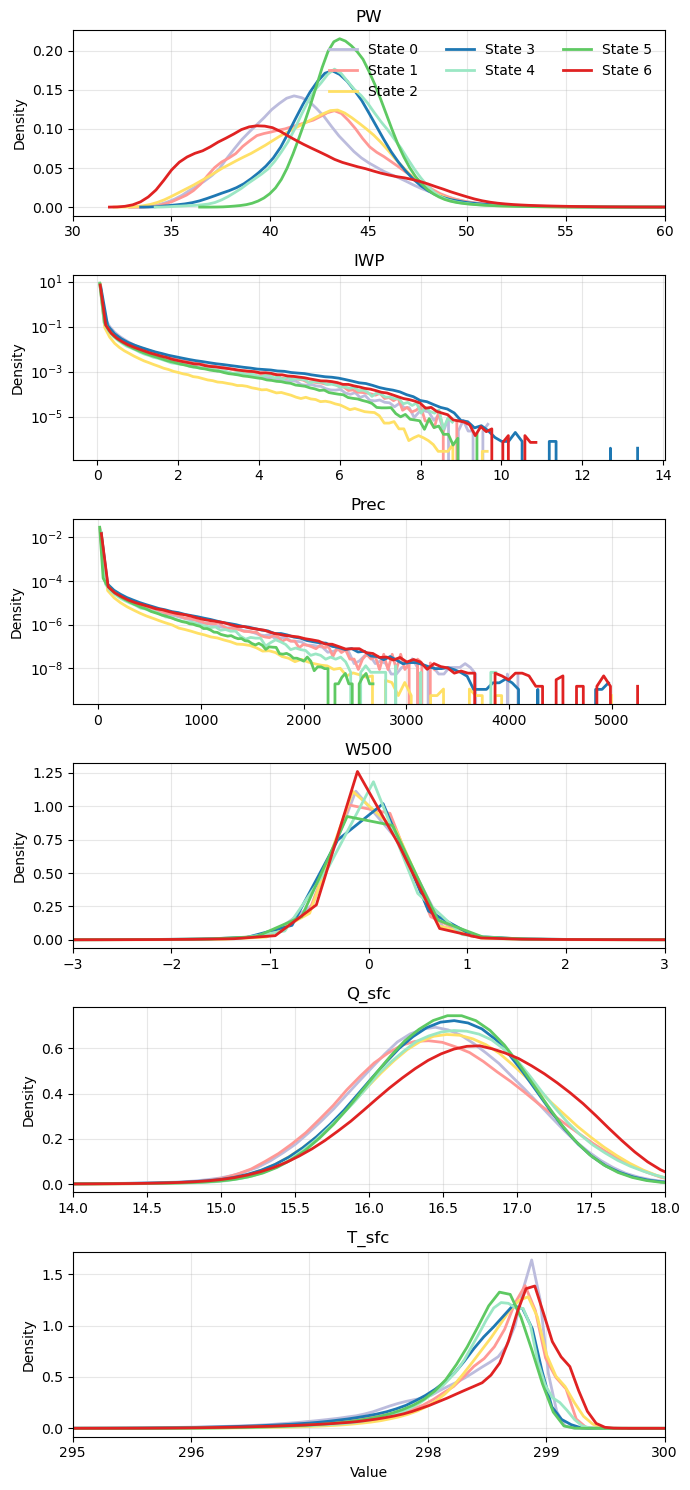

In [11]:
# ⚠️  Requires raw 2D fields on the LaCie drive.
data_dir = '/Volumes/LaCie/000_POSTDOC_2025/long_high_res/'
var_list = ["PW", "IWP", "Prec", "W500", "Q_sfc", "T_sfc"]
var_log  = {"IWP", "Prec"}
xlims    = {"PW": (30, 60), "W500": (-3, 3), "Q_sfc": (14, 18), "T_sfc": (295, 300)}

nx, ny, dtype     = 128, 128, np.float32
spatial_stride    = 2
nbins             = 80
nt                = states.shape[0]

data_2d = {
    var: np.memmap(os.path.join(data_dir, f"{var}_images_time_evolution.dat"),
                   dtype=dtype, mode="r", shape=(nt, nx, ny))
    for var in var_list
}

hists = {var: {} for var in var_list}
for var in var_list:
    for c in np.unique(states):
        idx    = np.where(states == c)[0]
        values = np.concatenate([data_2d[var][t, ::spatial_stride, ::spatial_stride].ravel()
                                 for t in idx])
        hist, edges = np.histogram(values, bins=nbins, density=True)
        hists[var][c] = (0.5 * (edges[:-1] + edges[1:]), hist)

fig, axes = plt.subplots(len(var_list), 1, figsize=(7, 2.5 * len(var_list)), sharex=False)
for ax, var in zip(axes, var_list):
    for c in np.unique(states):
        x, y = hists[var][c]
        ax.plot(x, y, lw=2, color=state_colors[c], label=f"State {c}")
    if var in var_log: ax.set_yscale("log")
    if xlims.get(var): ax.set_xlim(xlims[var])
    ax.set_title(f"{var}"); ax.set_ylabel("Density"); ax.grid(alpha=0.3)
axes[-1].set_xlabel("Value"); axes[0].legend(frameon=False, ncol=3)
plt.tight_layout()
plt.savefig(os.path.join(path_save_fig, "variable_distributions.pdf"))
plt.show()

## SI Fig. 11 — Canonical mean 2D fields (`fields_clusters.pdf`)

⚠️ Requires raw 2D fields on the LaCie external drive.  
Mean spatial map of each variable for the closest-to-centroid samples per state.

In [ ]:
# ⚠️ Requires raw 2D fields on the LaCie drive.
data_dir = '/Volumes/LaCie/000_POSTDOC_2025/long_high_res/'
var_list = ["PW", "IWP", "Prec", "W500", "Q_sfc", "T_sfc"]
vlims    = {
    "PW":    (30, 60),
    "IWP":   (0, 0.5),
    "Prec":  (0, 15),
    "W500":  (-3, 3),
    "Q_sfc": (14, 18),
    "T_sfc": (295, 300),
}

nx, ny   = 128, 128
dtype    = np.float32
nt       = states.shape[0]
clusters = sorted(state_keep_indices.keys())

# Pre-sort indices per state (sequential reads are faster on external disk)
closest_indices = {c: np.sort(state_keep_indices[c]) for c in clusters}

# Compute mean 2D field per variable per cluster
mean_fields = {var: {} for var in var_list}
for var in var_list:
    mmap = np.memmap(os.path.join(data_dir, f"{var}_images_time_evolution.dat"),
                     dtype=dtype, mode="r", shape=(nt, nx, ny))
    for c in clusters:
        mean_fields[var][c] = mmap[closest_indices[c]].mean(axis=0)
    del mmap

# ── Plot ──────────────────────────────────────────────────────
n_clusters = len(clusters)
n_vars     = len(var_list)

fig, axes = plt.subplots(
    n_clusters, n_vars,
    figsize=(3.5 * n_vars, 3.0 * n_clusters),
    squeeze=False,
)

for i, c in enumerate(clusters):
    for j, var in enumerate(var_list):
        ax  = axes[i, j]
        img = mean_fields[var][c]
        lim = vlims.get(var, (None, None))
        im  = ax.imshow(img, origin="lower", vmin=lim[0], vmax=lim[1])
        if i == 0:
            ax.set_title(var, fontsize=13)
        if j == 0:
            ax.set_ylabel(f"Cluster {c}", fontsize=13)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Canonical mean fields per latent state", fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(path_save_fig, "fields_clusters.pdf"))
plt.show()